In [4]:
import pandas as pd
import numpy as np

# 1. Carga de datos
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# 2. Definimos las columnas que NO podemos borrar (Demografía, Sueldos, Experiencia)
# Estas son las que usás en las 3 páginas del Dashboard y en el Lab de Python
cols_esenciales = [
    'ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'EdLevel', 'Country',
    'CompTotal', 'ConvertedCompYearly', 'WorkExp', 'TimeSearching', 'TimeAnswering', 'Frustration',
    'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith',
    'PlatformHaveWorkedWith', 'PlatformWantToWorkWith',
    'WebframeHaveWorkedWith', 'WebframeWantToWorkWith'
]

# Creamos una copia con solo lo necesario para que el peso baje de 100MB
df_final = df[cols_esenciales].copy()

# 3. Función modular para procesar cualquier categoría
def encode_tech_stack(df_source, df_target, current_col, future_col, prefix):
    print(f"Procesando {prefix}...")
    
    # Identificar todos los valores únicos en ambas columnas
    all_items = set()
    for col in [current_col, future_col]:
        items = df_source[col].dropna().str.split(';').explode().unique()
        all_items.update(items)
    
    # Limpiar nombres (quitar 'Unknown' o vacíos)
    all_items = sorted([i for i in all_items if i and i != 'Unknown'])
    
    for item in all_items:
        # Creamos nombre de columna técnica (ej: DB_PostgreSQL)
        col_name = f"{prefix}_{item}"
        df_target[col_name] = 0
        
        pattern = re.escape(item)
        
        # 1: Trabajó (Current)
        worked = df_source[current_col].str.contains(fr'(?:^|;){pattern}(?:$|;)', na=False)
        df_target.loc[worked, col_name] = 1
        
        # 2: Desea (Future) - Según tu lógica, pisa al 1 si hay interés futuro
        want = df_source[future_col].str.contains(fr'(?:^|;){pattern}(?:$|;)', na=False)
        df_target.loc[want, col_name] = 2

# 4. Ejecutamos la función para cada par de columnas
tech_pairs = [
    ('LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'Lang'),
    ('DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'DB'),
    ('PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'Plat'),
    ('WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'Web')
]

for current, future, prefix in tech_pairs:
    encode_tech_stack(df, df_final, current, future, prefix)

# 5. Guardar el "Master File" para Looker
df_final.to_csv('survey_master_encoded.csv', index=False)

print("\n--- RESUMEN FINAL ---")
print(f"Total de columnas: {len(df_final.columns)}")
print(f"Tamaño estimado: {df_final.memory_usage().sum() / 1e6:.2f} MB")

Procesando Lang...
Procesando DB...
Procesando Plat...


C:\Users\Hp\AppData\Local\Temp\ipykernel_27992\418781979.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_target[col_name] = 0
C:\Users\Hp\AppData\Local\Temp\ipykernel_27992\418781979.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_target[col_name] = 0
C:\Users\Hp\AppData\Local\Temp\ipykernel_27992\418781979.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(ax

Procesando Web...


C:\Users\Hp\AppData\Local\Temp\ipykernel_27992\418781979.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_target[col_name] = 0
C:\Users\Hp\AppData\Local\Temp\ipykernel_27992\418781979.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_target[col_name] = 0
C:\Users\Hp\AppData\Local\Temp\ipykernel_27992\418781979.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(ax


--- RESUMEN FINAL ---
Total de columnas: 166
Tamaño estimado: 86.90 MB


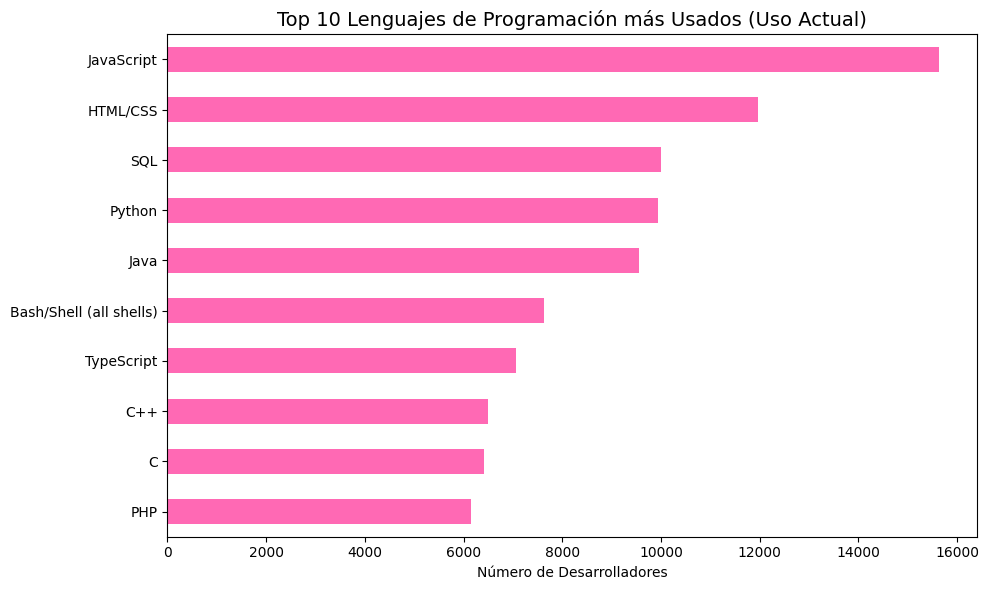

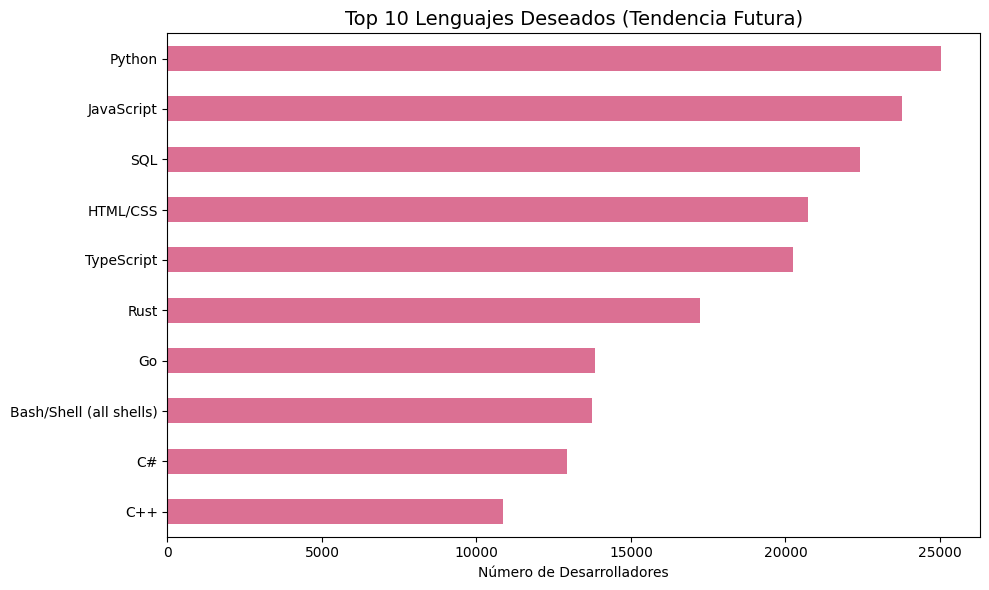

Gráficos generados con éxito para las Slides 10 y 11.


In [6]:
import matplotlib.pyplot as plt

# 1. Cargamos el dataset maestro que creamos
df = pd.read_csv('survey_master_encoded.csv')

# 2. Filtramos solo las columnas de lenguajes
lang_cols = [col for col in df.columns if col.startswith('Lang_')]

# --- GRÁFICO 1: TOP 10 USO ACTUAL (Valor 1) ---
# Contamos cuántas veces aparece el 1 en cada columna
current_usage = (df[lang_cols] == 1).sum().sort_values(ascending=False).head(10)
# Limpiamos los nombres (quitamos el prefijo 'Lang_')
current_usage.index = [i.replace('Lang_', '') for i in current_usage.index]

plt.figure(figsize=(10, 6))
current_usage.plot(kind='barh', color='hotpink') # Color rosa profesional
plt.title('Top 10 Lenguajes de Programación más Usados (Uso Actual)', fontsize=14)
plt.xlabel('Número de Desarrolladores')
plt.gca().invert_yaxis() # Para que el #1 quede arriba
plt.tight_layout()
plt.savefig('top10_current_languages.png')
plt.show()

# --- GRÁFICO 2: TOP 10 TENDENCIA FUTURA (Valor 2) ---
# Contamos cuántas veces aparece el 2 en cada columna
future_trends = (df[lang_cols] == 2).sum().sort_values(ascending=False).head(10)
future_trends.index = [i.replace('Lang_', '') for i in future_trends.index]

plt.figure(figsize=(10, 6))
future_trends.plot(kind='barh', color='palevioletred') # Un rosa distinto para variar
plt.title('Top 10 Lenguajes Deseados (Tendencia Futura)', fontsize=14)
plt.xlabel('Número de Desarrolladores')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top10_future_languages.png')
plt.show()

print("Gráficos generados con éxito para las Slides 10 y 11.")

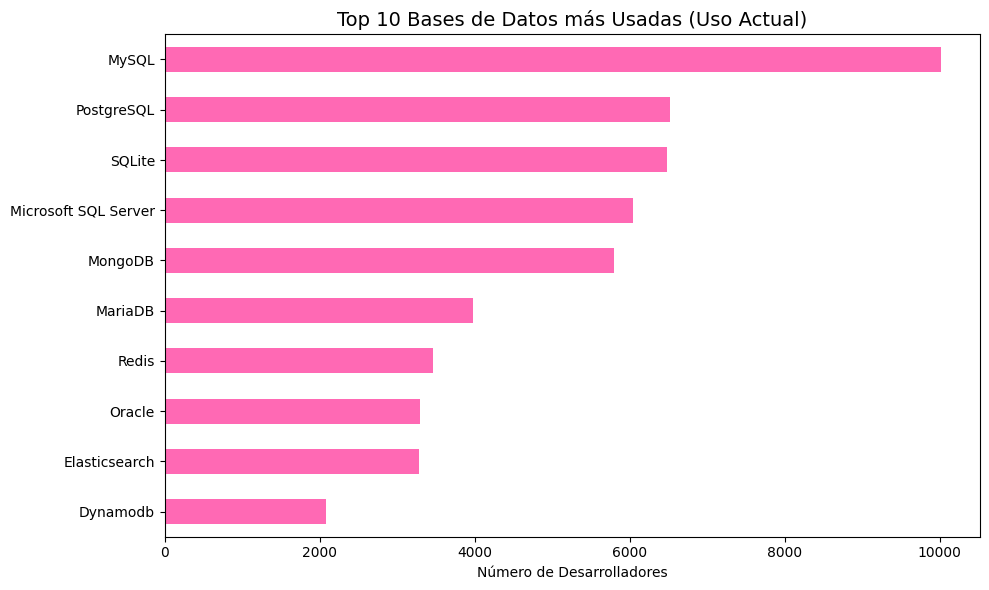

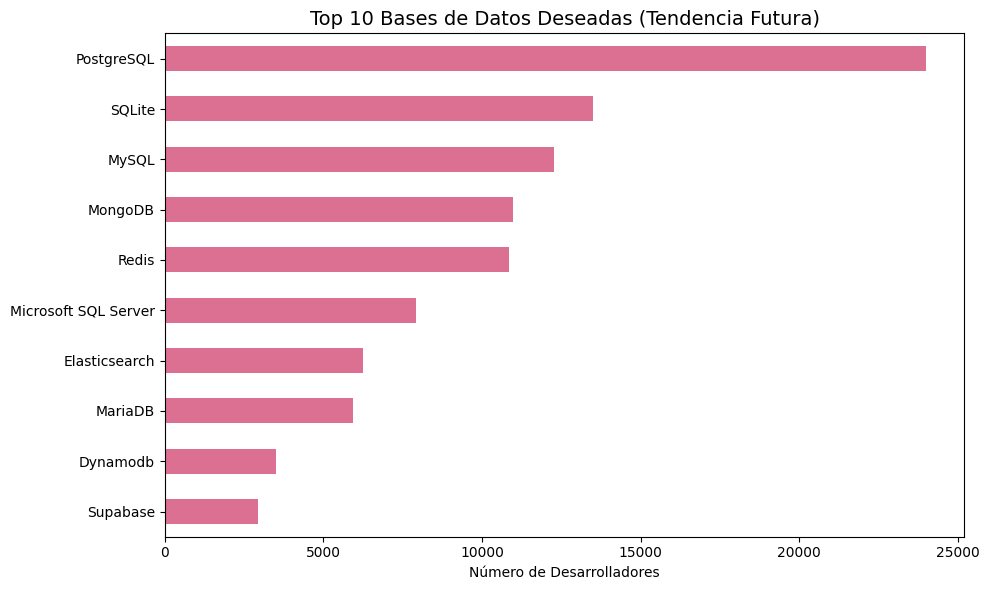

In [7]:
# 2. Filtramos las columnas de Bases de Datos (prefijo DB_)
db_cols = [col for col in df.columns if col.startswith('DB_')]

# --- GRÁFICO 1: TOP 10 BASES DE DATOS - USO ACTUAL (Valor 1) ---
current_db = (df[db_cols] == 1).sum().sort_values(ascending=False).head(10)
current_db.index = [i.replace('DB_', '') for i in current_db.index]

plt.figure(figsize=(10, 6))
current_db.plot(kind='barh', color='hotpink')
plt.title('Top 10 Bases de Datos más Usadas (Uso Actual)', fontsize=14)
plt.xlabel('Número de Desarrolladores')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top10_current_databases.png')
plt.show()

# --- GRÁFICO 2: TOP 10 BASES DE DATOS - TENDENCIA FUTURA (Valor 2) ---
future_db = (df[db_cols] == 2).sum().sort_values(ascending=False).head(10)
future_db.index = [i.replace('DB_', '') for i in future_db.index]

plt.figure(figsize=(10, 6))
future_db.plot(kind='barh', color='palevioletred')
plt.title('Top 10 Bases de Datos Deseadas (Tendencia Futura)', fontsize=14)
plt.xlabel('Número de Desarrolladores')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top10_future_databases.png')
plt.show()